# Inflation Analytics from VkusVill Data (ClickHouse)

**Hypothesis:** the Central Bank of Russia's official inflation estimate is **5.3%** (annual).

**What we check on our data:**
1. For each product, take the price on the first observation day and the price on the last observation day.
2. Compute the delta (price change).
3. Average the deltas across all pairs and compare with the Central Bank estimate.

*A simplified toy model for a student project — not methodologically rigorous.*

In [1]:
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt

CB_INFLATION_PCT = 5.3  # Central Bank official estimate, %
DB = 'vkusvill_db'
TABLE = 'products'

client = clickhouse_connect.get_client(
    host='158.160.231.239',
    port=8123,
    username='clickaa',
    password='susan090',
)

## 1. Data Overview

Check the time period covered by the price data and how many records are in the table.

In [2]:
overview = client.query_df(f"""
    SELECT
        count(*) AS total_rows,
        count(DISTINCT url) AS unique_products,
        count(DISTINCT toDate(parsed_at)) AS unique_days,
        min(toDate(parsed_at)) AS period_start,
        max(toDate(parsed_at)) AS period_end
    FROM {DB}.{TABLE}
    WHERE price IS NOT NULL AND url IS NOT NULL
""")

overview

,total_rows,unique_products,unique_days,period_start,period_end
0,824227,30363,45,2026-05-08,2026-06-25


## 2. First-Price / Last-Price Pairs

For each product (`url`):
1. First aggregate prices **by day** (median is robust to duplicate scrape rows).
2. Take the price on the **first** and **last** observation day.

Only products seen on at least **two different days** are included.

In [3]:
pairs_query = f"""
    WITH daily AS (
        SELECT
            url,
            any(title) AS title,
            any(category) AS category,
            toDate(parsed_at) AS day,
            median(price) AS day_price
        FROM {DB}.{TABLE}
        WHERE price IS NOT NULL AND url IS NOT NULL AND price > 0
        GROUP BY url, day
    )
    SELECT
        url,
        any(title) AS title,
        any(category) AS category,
        min(day) AS first_day,
        max(day) AS last_day,
        argMin(day_price, day) AS price_first,
        argMax(day_price, day) AS price_last
    FROM daily
    GROUP BY url
    HAVING count(*) >= 2 AND price_first > 0
"""

pairs_df = client.query_df(pairs_query)
pairs_df.head(10)

,url,title,category,first_day,last_day,price_first,price_last
0,https://vkusvill.ru/goods/nut-bonduelle-v-sous...,Нут Bonduelle в соусе с черносливом с/б 360 г ...,Овощные консервы,2026-05-18,2026-06-25,205.0,205.0
1,https://vkusvill.ru/goods/ris-na-paru-150-g-29...,"Рис на пару, 150 г",ЗОЖ,2026-05-08,2026-05-17,135.0,135.0
2,https://vkusvill.ru/goods/khumus-s-gribami-110...,"Хумус с грибами, 50 г","Консервы, мёд и варенье",2026-05-18,2026-06-25,62.0,62.0
3,https://vkusvill.ru/goods/yazyk-govyazhiy-gp-2...,Язык говяжий ГП,"Мясо, птица",2026-05-08,2026-05-17,1497.0,1497.0
4,https://vkusvill.ru/goods/vafelnye-rulety-pikk...,"Вафельные рулеты ""Пикколо""",Сладости и десерты,2026-05-08,2026-05-17,108.0,108.0
5,https://vkusvill.ru/goods/morozhenoe-molochnoe...,Мороженое молочное с вишней в ваф. стаканчике,Замороженные продукты,2026-05-18,2026-06-25,88.0,88.0
6,https://vkusvill.ru/goods/morozhenoe-s-protein...,"Мороженое с протеином ""Солёная карамель с арах...",Мороженое,2026-05-08,2026-05-17,158.0,158.0
7,https://vkusvill.ru/goods/bitochki-iz-tsyplenk...,"Биточки из цыпленка с сыром, зам., 650 г",Замороженные продукты,2026-05-18,2026-06-25,637.0,637.0
8,https://vkusvill.ru/goods/nabor-pirozhnykh-mak...,"Набор пирожных макарон ""Ваниль, фисташка, соле...",Кафе,2026-05-08,2026-05-17,482.0,482.0
9,https://vkusvill.ru/goods/lopatka-svinaya-besk...,"Лопатка свиная бескостная охл., вес","Мясо, птица",2026-05-18,2026-06-25,585.0,585.0


## 3. Delta Calculation

- **delta_abs** = `price_last − price_first` (RUB)
- **delta_pct** = `(price_last − price_first) / price_first × 100` (%)

In [4]:
pairs_df['delta_abs'] = pairs_df['price_last'] - pairs_df['price_first']
pairs_df['delta_pct'] = pairs_df['delta_abs'] / pairs_df['price_first'] * 100

pairs_df[['title', 'price_first', 'price_last', 'delta_abs', 'delta_pct']].head(10)

,title,price_first,price_last,delta_abs,delta_pct
0,Нут Bonduelle в соусе с черносливом с/б 360 г ...,205.0,205.0,0.0,0.0
1,"Рис на пару, 150 г",135.0,135.0,0.0,0.0
2,"Хумус с грибами, 50 г",62.0,62.0,0.0,0.0
3,Язык говяжий ГП,1497.0,1497.0,0.0,0.0
4,"Вафельные рулеты ""Пикколо""",108.0,108.0,0.0,0.0
5,Мороженое молочное с вишней в ваф. стаканчике,88.0,88.0,0.0,0.0
6,"Мороженое с протеином ""Солёная карамель с арах...",158.0,158.0,0.0,0.0
7,"Биточки из цыпленка с сыром, зам., 650 г",637.0,637.0,0.0,0.0
8,"Набор пирожных макарон ""Ваниль, фисташка, соле...",482.0,482.0,0.0,0.0
9,"Лопатка свиная бескостная охл., вес",585.0,585.0,0.0,0.0


### Top 10 products by price change

`.head(10)` returns the **first** 10 rows, not the largest changes. Use `.nlargest()` or `.sort_values()` instead.

In [5]:
TOP_N = 10

# Top 10 by % change (best for comparing inflation across products)
top_by_pct = (
    pairs_df[['title', 'category', 'price_first', 'price_last', 'delta_abs', 'delta_pct']]
    .nlargest(TOP_N, 'delta_pct')
)

# Alternative: top 10 by absolute RUB change
# top_by_rub = pairs_df.nlargest(TOP_N, 'delta_abs')

top_by_pct

,title,category,price_first,price_last,delta_abs,delta_pct
20496,Лед пищевой (куб 5х5 см),Напитки,58.0,290.0,232.0,400.000000
1247,Ароматическое саше Chirton Лимонная свежесть 1...,Освежители и ароматизаторы,29.0,122.0,93.0,320.689655
4085,Тетрадь на кольцах BG Accent color А5 160 лист...,Тетради школьные и общие,99.0,366.0,267.0,269.696970
23867,Мицеллярный гель для умывания Himalaya since 1...,Для умывания,159.0,542.0,383.0,240.880503
13833,Крем-краска для волос Сьёсс Стойкое окрашивани...,Главная,139.0,472.0,333.0,239.568345
13817,"Завиток с корицей, зам. кафе",Кафе,32.0,108.0,76.0,237.500000
6592,Лёд из пюре Дыни,Замороженные продукты,20.0,65.0,45.0,225.000000
92,Папка для акварели А4 Гамма Студия 15 листов /...,"Альбомы, папки для рисования, раскраски",79.0,217.0,138.0,174.683544
24387,Пенал школьный Феникс+ Арбузер без наполнения ...,Папки и пеналы,99.0,252.0,153.0,154.545455
23719,Зубная паста Himalaya Since 1930 Свежая мята 7...,Зубные пасты,149.0,377.0,228.0,153.020134


## 4. Average Delta vs. Central Bank Estimate

In [6]:
avg_delta_abs = pairs_df['delta_abs'].mean()
avg_delta_pct = pairs_df['delta_pct'].mean()
median_delta_pct = pairs_df['delta_pct'].median()

increased = (pairs_df['delta_pct'] > 0).sum()
unchanged = (pairs_df['delta_pct'] == 0).sum()
decreased = (pairs_df['delta_pct'] < 0).sum()

summary = pd.DataFrame({
    'Metric': [
        'Number of product pairs',
        'Average delta, RUB',
        'Average delta, %',
        'Median delta, %',
        'Central Bank estimate, %',
        'Difference (ours − CB), pp',
        'Products with price increase',
        'Products unchanged',
        'Products with price decrease',
    ],
    'Value': [
        len(pairs_df),
        round(avg_delta_abs, 2),
        round(avg_delta_pct, 2),
        round(median_delta_pct, 2),
        CB_INFLATION_PCT,
        round(avg_delta_pct - CB_INFLATION_PCT, 2),
        increased,
        unchanged,
        decreased,
    ],
})

summary

,Metric,Value
0,Number of product pairs,29244.00
1,"Average delta, RUB",1.15
2,"Average delta, %",0.52
3,"Median delta, %",0.00
4,"Central Bank estimate, %",5.30
5,"Difference (ours − CB), pp",-4.78
6,Products with price increase,2580.00
7,Products unchanged,25171.00
8,Products with price decrease,1493.00


## 5. Consumer Price Basket (CPI-style)

Russia's consumer basket includes 13 product groups. For each group we pick **one ordinary staple product** from VkusVill data and track its price change from the first to the last observation day.

**How products are chosen:**
1. Match by **title keywords** for the basket group (e.g. `^Молоко ` for milk, `^Сахар ` for sugar).
2. **Exclude** non-staples: pet food, ready meals, sushi, coconut/specialty variants, smoked salt, etc.
3. **Fish** must be **frozen** (`зам` / `заморож`) raw fish — not sushi or prepared dishes.
4. Among matches, prefer the product with the **longest observation period**, then the **shortest/simplest title** (basic grocery item, not a niche variant).

| # | Basket group |
|---|--------------|
| 1 | Bread products: bread, pasta, flour |
| 2 | Cereals |
| 3 | Legumes |
| 4 | Potatoes |
| 5 | Vegetables and melons |
| 6 | Fresh fruits |
| 7 | Sugar and confectionery (sugar) |
| 8 | Meat products |
| 9 | Fish products |
| 10 | Milk and dairy products (milk) |
| 11 | Eggs |
| 12 | Vegetable oil, margarine and other fats |
| 13 | Other products (salt, tea, spices) |

In [7]:
import re

# Global exclusions: not grocery staples for CPI basket
BASKET_EXCLUDE = re.compile(
    r'корм|кош|собак|almo|award|8in1|игруш|альбом|желе|вафл|блинчик|'
    r'котлет|ассорти|маринован|консерв|суши|ролл',
    re.I,
)

# Per-group rules: patterns + optional extra exclude / category / frozen-fish filter
CONSUMER_BASKET = [
    {'group': 'Bread, pasta, flour', 'patterns': ['100% ржаной', 'Батон ', 'Макаронные изделия', 'Мука ']},
    {'group': 'Cereals', 'patterns': ['Крупа гречневая', 'Гречка ядрица', 'Пшено ', 'Рис ']},
    {'group': 'Legumes', 'patterns': ['Фасоль ', 'Горох ', 'Чечевица', 'Нут ']},
    {'group': 'Potatoes', 'patterns': ['^Картофель$']},
    {'group': 'Vegetables and melons', 'patterns': ['^Огурц', '^Морков', '^Капуст', '^Помидор']},
    {'group': 'Fresh fruits', 'patterns': ['^Апельсин', '^Яблок', '^Банан', '^Груш']},
    {
        'group': 'Sugar and confectionery',
        'patterns': [r'^Сахар ', r'сахарный песок'],
        'exclude': r'кокос|тростник|пальм',  # ordinary white/beet sugar only
    },
    {'group': 'Meat products', 'patterns': ['говядин', 'свинин', 'курин', 'колбас', 'индейк']},
    {
        'group': 'Fish products',
        'patterns': [r'зам', r'заморож'],
        'also_match': r'лосос|треск|форел|семг|сельд|скумбр|филе|минт|хек|рыб',
        'exclude': r'суши|котлет|консерв|копчен|готов',
        'category': r'рыб|мореп',
    },
    {
        'group': 'Milk and dairy',
        'patterns': [r'^Молоко '],
        'exclude': r'кокос|сух|раститель|соев|миндаль|коз|кокосов|углевод',  # plain cow milk only
    },
    {'group': 'Eggs', 'patterns': ['Яйцо куриное', 'яйц']},
    {
        'group': 'Vegetable oil and fats',
        'patterns': [r'Масло подсолнеч'],
        'exclude': r'олив|кокос|трюф',  # ordinary sunflower oil
    },
    {
        'group': 'Other (salt, tea, spices)',
        'patterns': [r'^Соль ', r'^Чай '],
        'exclude': r'копчен|морск|гималай|Salicornia|селитр',  # ordinary table salt
    },
]


def pick_basket_product(cfg):
    """Pick the best ordinary staple for one basket group."""
    pool = pairs_df[~pairs_df['title'].str.contains(BASKET_EXCLUDE, na=False)].copy()

    if cfg.get('exclude'):
        pool = pool[~pool['title'].str.contains(cfg['exclude'], case=False, na=False)]

    if cfg.get('category'):
        pool = pool[pool['category'].str.contains(cfg['category'], case=False, na=False)]

    if cfg.get('also_match'):
        pool = pool[pool['title'].str.contains(cfg['also_match'], case=False, na=False, regex=True)]

    pool['obs_days'] = (pool['last_day'] - pool['first_day']).dt.days

    for pattern in cfg['patterns']:
        matches = pool.loc[pool['title'].str.contains(pattern, case=False, na=False, regex=True)]
        if not matches.empty:
            return (
                matches
                .assign(_len=matches['title'].str.len())
                .sort_values(['obs_days', '_len'], ascending=[False, True])
                .iloc[0]
            )
    return None


basket_rows = []
for cfg in CONSUMER_BASKET:
    row = pick_basket_product(cfg)
    group = cfg['group']
    if row is None:
        basket_rows.append({'Basket group': group, 'Product': '— not found in data —'})
        continue
    basket_rows.append({
        'Basket group': group,
        'Product': row['title'],
        'Category': row['category'],
        'First day': row['first_day'],
        'Last day': row['last_day'],
        'First price, RUB': int(row['price_first']),
        'Last price, RUB': int(row['price_last']),
        'Delta, RUB': int(row['delta_abs']),
        'Delta, %': round(row['delta_pct'], 2),
    })

basket_df = pd.DataFrame(basket_rows)
basket_df

,Basket group,Product,Category,First day,Last day,"First price, RUB","Last price, RUB","Delta, RUB","Delta, %"
0,"Bread, pasta, flour","Хлеб ""100% ржаной на закваске"" солодовый",Хлеб и выпечка,2026-05-18,2026-06-25,110,114,4,3.64
1,Cereals,Крупа гречневая (пакетики),Бакалея без глютена,2026-05-18,2026-06-25,88,88,0,0.00
2,Legumes,Фасоль печеная с перцем,"Консервы, мёд и варенье",2026-05-18,2026-06-25,153,153,0,0.00
3,Potatoes,Картофель,Овощи,2026-05-18,2026-06-25,58,58,0,0.00
4,Vegetables and melons,Огурцы гладкие,Овощи,2026-05-18,2026-06-25,145,195,50,34.48
5,Fresh fruits,Апельсины,Фрукты,2026-05-18,2026-06-25,130,130,0,0.00
6,Sugar and confectionery,"Сахар белый ""Экстра"", 1 кг","Масла, соусы, специи, сахар и соль",2026-05-18,2026-06-25,140,140,0,0.00
7,Meat products,Мякоть говядины,"Мясо, птица",2026-05-18,2026-06-25,855,910,55,6.43
8,Fish products,Карп филе зам.,"Рыба, икра и морепродукты",2026-05-18,2026-06-25,1237,1237,0,0.00
9,Milk and dairy,"Молоко Parmalat Comfort Безлактозное 1,8% 1 л",Продукты без лактозы,2026-05-18,2026-06-25,211,211,0,0.00


In [8]:
found = basket_df['Delta, %'].notna()
basket_avg_delta_pct = basket_df.loc[found, 'Delta, %'].mean()
basket_avg_delta_abs = basket_df.loc[found, 'Delta, RUB'].mean()

basket_summary = pd.DataFrame({
    'Metric': [
        'Products selected',
        'Average price change, %',
        'Average price change, RUB',
        'Central Bank estimate, %',
        'Difference (basket − CB), pp',
    ],
    'Value': [
        int(found.sum()),
        round(basket_avg_delta_pct, 2),
        round(basket_avg_delta_abs, 2),
        CB_INFLATION_PCT,
        round(basket_avg_delta_pct - CB_INFLATION_PCT, 2),
    ],
})

basket_summary

,Metric,Value
0,Products selected,13.00
1,"Average price change, %",3.76
2,"Average price change, RUB",8.54
3,"Central Bank estimate, %",5.30
4,"Difference (basket − CB), pp",-1.54


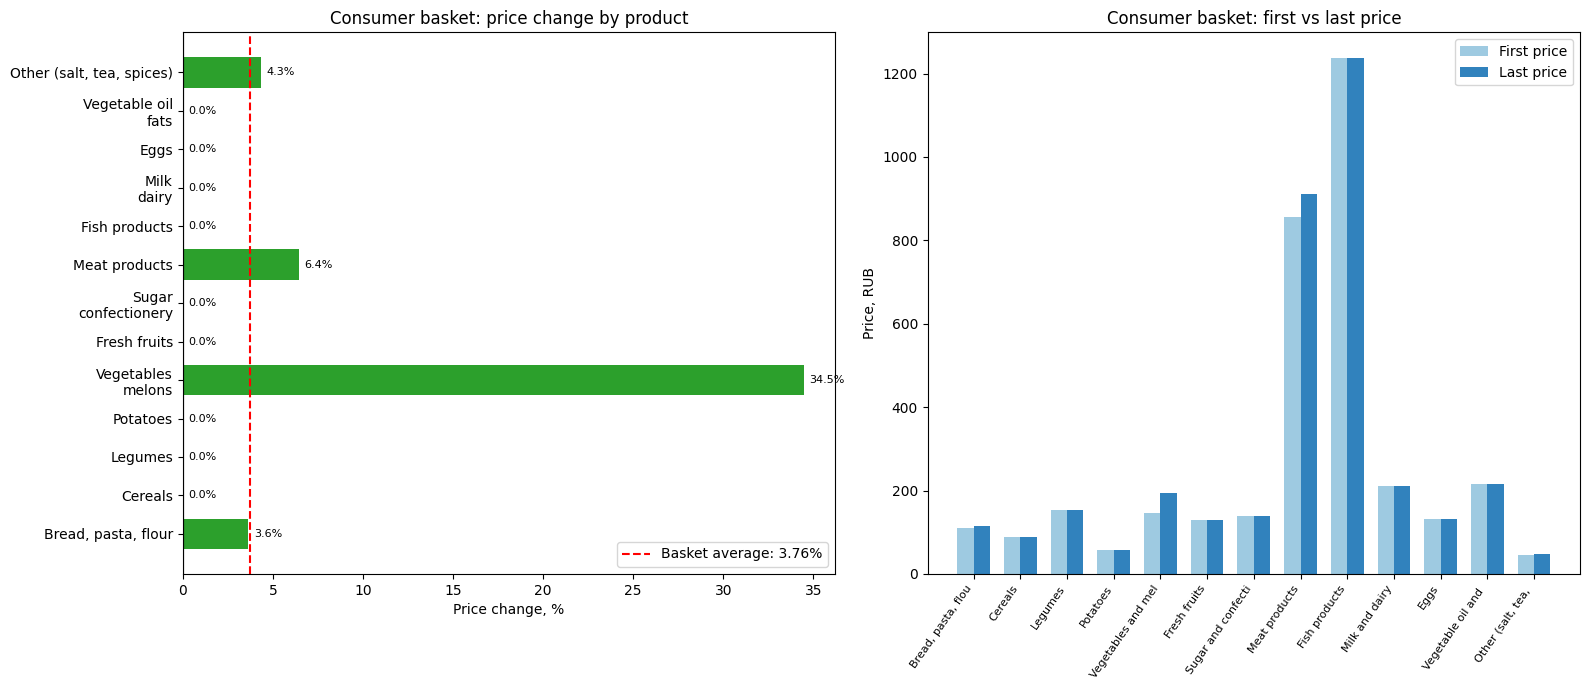

In [9]:
plot_df = basket_df.loc[found].copy()
plot_df['short_label'] = plot_df['Basket group'].str.replace(' and ', '\n', regex=False)

colors = ['#2ca02c' if v > 0 else '#d62728' if v < 0 else '#7f7f7f' for v in plot_df['Delta, %']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Per-product price change
bars = axes[0].barh(plot_df['short_label'], plot_df['Delta, %'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(basket_avg_delta_pct, color='red', linestyle='--', label=f'Basket average: {basket_avg_delta_pct:.2f}%')
axes[0].set_xlabel('Price change, %')
axes[0].set_title('Consumer basket: price change by product')
axes[0].legend(loc='lower right')
for bar, val in zip(bars, plot_df['Delta, %']):
    axes[0].text(val + (0.3 if val >= 0 else -0.3), bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

# First vs last price for each product
x = range(len(plot_df))
width = 0.35
axes[1].bar([i - width / 2 for i in x], plot_df['First price, RUB'], width, label='First price', color='#9ecae1')
axes[1].bar([i + width / 2 for i in x], plot_df['Last price, RUB'], width, label='Last price', color='#3182bd')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([g[:18] for g in plot_df['Basket group']], rotation=55, ha='right', fontsize=8)
axes[1].set_ylabel('Price, RUB')
axes[1].set_title('Consumer basket: first vs last price')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Visualization

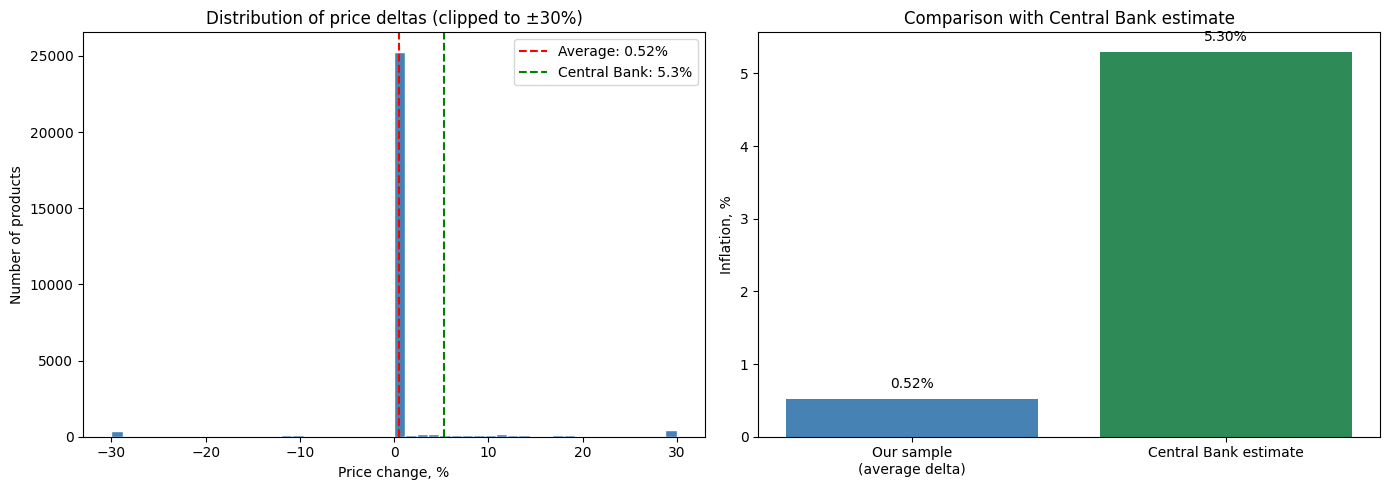

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (clip X-axis for readability; outliers are rare)
clip = 30
axes[0].hist(
    pairs_df['delta_pct'].clip(-clip, clip),
    bins=50,
    color='steelblue',
    edgecolor='white',
)
axes[0].axvline(avg_delta_pct, color='red', linestyle='--', label=f'Average: {avg_delta_pct:.2f}%')
axes[0].axvline(CB_INFLATION_PCT, color='green', linestyle='--', label=f'Central Bank: {CB_INFLATION_PCT}%')
axes[0].set_xlabel('Price change, %')
axes[0].set_ylabel('Number of products')
axes[0].set_title(f'Distribution of price deltas (clipped to ±{clip}%)')
axes[0].legend()

labels = ['Our sample\n(average delta)', 'Central Bank estimate']
values = [avg_delta_pct, CB_INFLATION_PCT]
colors = ['steelblue', 'seagreen']
bars = axes[1].bar(labels, values, color=colors)
axes[1].set_ylabel('Inflation, %')
axes[1].set_title('Comparison with Central Bank estimate')
for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{val:.2f}%',
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

## 7. Analysis by Category

Inflation is not uniform across the store. Some categories barely move (e.g. children's products), while others show clearer price growth (e.g. bread).

We group products by `category` and compute the same average delta per category. Categories with fewer than `MIN_PRODUCTS` items are excluded to avoid noisy estimates.

In [11]:
MIN_PRODUCTS = 20

category_stats = (
    pairs_df.groupby('category', as_index=False)
    .agg(
        products=('url', 'count'),
        avg_delta_pct=('delta_pct', 'mean'),
        median_delta_pct=('delta_pct', 'median'),
        share_increased_pct=('delta_pct', lambda s: (s > 0).mean() * 100),
    )
    .query('products >= @MIN_PRODUCTS')
    .sort_values('avg_delta_pct', ascending=False)
    .reset_index(drop=True)
)

category_stats['vs_cb_pp'] = category_stats['avg_delta_pct'] - CB_INFLATION_PCT

category_stats.head(15)

,category,products,avg_delta_pct,median_delta_pct,share_increased_pct,vs_cb_pp
0,Косметические наборы,25,24.729060,0.000000,28.000000,19.429060
1,Оливковое масло,36,17.222735,0.000000,36.111111,11.922735
2,Перчатки,20,16.227836,1.187335,50.000000,10.927836
3,Средства для купания,22,11.923733,0.000000,27.272727,6.623733
4,Твёрдые сыры,26,11.801877,0.000000,26.923077,6.501877
5,Освежители и ароматизаторы,33,11.163588,0.000000,15.151515,5.863588
6,Для стирки и уборки,20,11.038190,0.000000,45.000000,5.738190
7,Зубные пасты,62,10.494002,0.000000,29.032258,5.194002
8,Средства для посудомоечных машин,30,9.007638,0.000000,33.333333,3.707638
9,Кондиционеры,62,8.867797,0.000000,25.806452,3.567797


In [12]:
# Categories mentioned in the hypothesis — matched by keyword in case of spelling variants
HIGHLIGHT_KEYWORDS = ['дет', 'хлеб']

highlight_rows = []
for keyword in HIGHLIGHT_KEYWORDS:
    mask = category_stats['category'].str.contains(keyword, case=False, na=False)
    highlight_rows.append(category_stats.loc[mask])

highlight_df = pd.concat(highlight_rows).drop_duplicates(subset='category')
highlight_df = highlight_df.sort_values('avg_delta_pct', ascending=False)

highlight_df[['category', 'products', 'avg_delta_pct', 'median_delta_pct', 'vs_cb_pp']]

,category,products,avg_delta_pct,median_delta_pct,vs_cb_pp
49,Хлеб,38,3.207291,0.0,-2.092709
55,Детское молочное питание,29,2.786770,0.0,-2.513230
110,Хлеб и выпечка,444,0.269418,0.0,-5.030582
122,Хлебцы,34,0.061183,0.0,-5.238817
132,Хлеб и выпечка из нашей пекарни,70,0.000000,0.0,-5.300000
156,Товары для детей,345,-1.071491,0.0,-6.371491
170,"Детское развитие, творчество и игры",896,-3.420730,0.0,-8.720730


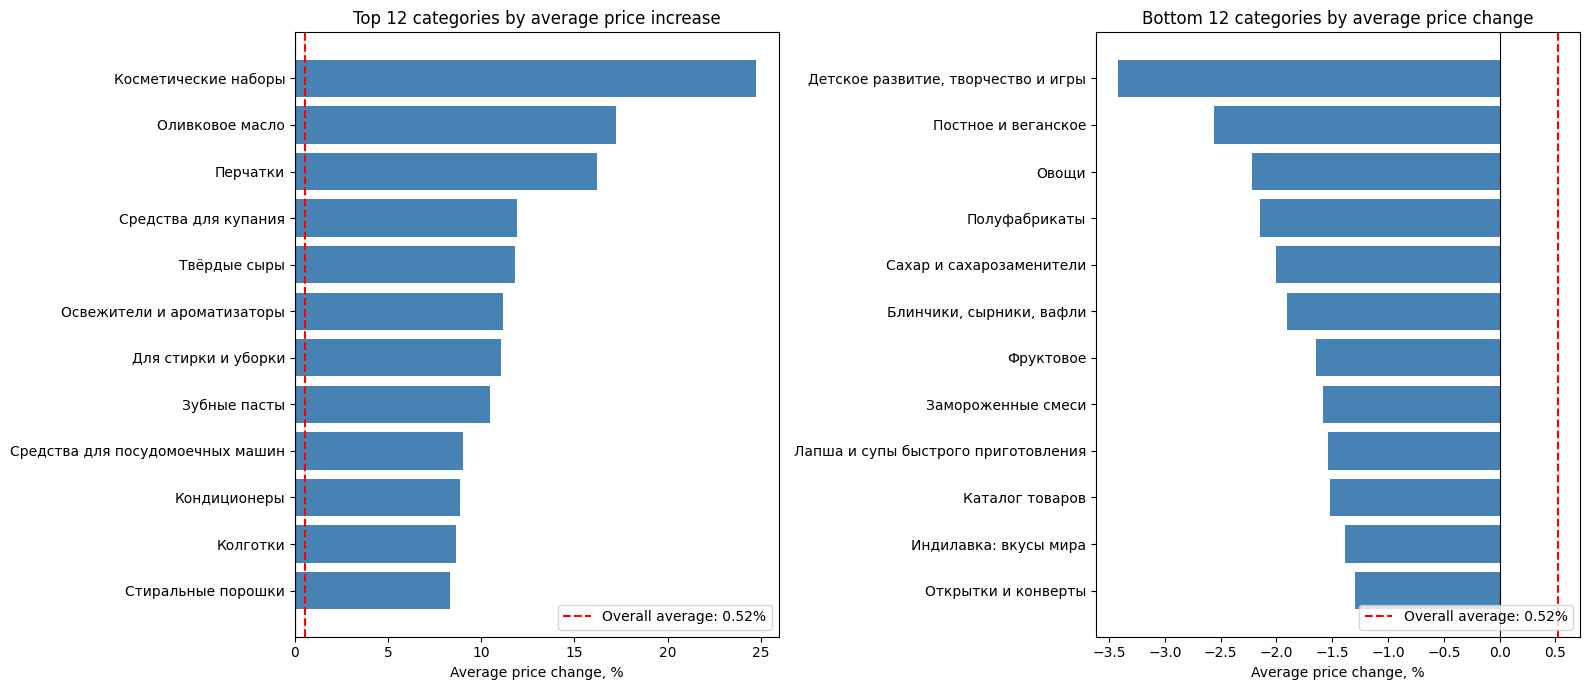

In [13]:
n_show = 12
top = category_stats.head(n_show).iloc[::-1]
bottom = category_stats.tail(n_show)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title in [
    (axes[0], top, f'Top {n_show} categories by average price increase'),
    (axes[1], bottom, f'Bottom {n_show} categories by average price change'),
]:
    bars = ax.barh(data['category'], data['avg_delta_pct'], color='steelblue')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline(avg_delta_pct, color='red', linestyle='--', label=f'Overall average: {avg_delta_pct:.2f}%')
    ax.set_xlabel('Average price change, %')
    ax.set_title(title)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [14]:
# Compare selected categories side by side
COMPARE_GROUPS = {
    "Children's products": ['Товары для\u00a0детей', 'детск'],
    'Bread': ['^Хлеб$', 'хлеб'],
}


def pick_category_row(keywords):
    for keyword in keywords:
        if keyword.startswith('^'):
            mask = category_stats['category'].str.contains(keyword, case=False, na=False, regex=True)
        else:
            mask = category_stats['category'].str.contains(keyword, case=False, na=False)
        match = category_stats.loc[mask]
        if not match.empty:
            return match.sort_values('products', ascending=False).iloc[0]
    return None


compare_rows = []
for label, keywords in COMPARE_GROUPS.items():
    row = pick_category_row(keywords)
    if row is None:
        continue
    compare_rows.append({
        'Group': label,
        'Category': row['category'],
        'Products': int(row['products']),
        'Avg delta, %': round(row['avg_delta_pct'], 2),
        'Median delta, %': round(row['median_delta_pct'], 2),
    })

compare_df = pd.DataFrame(compare_rows)
compare_df

,Group,Category,Products,"Avg delta, %","Median delta, %"
0,Children's products,Товары для детей,345,-1.07,0.0
1,Bread,Хлеб,38,3.21,0.0


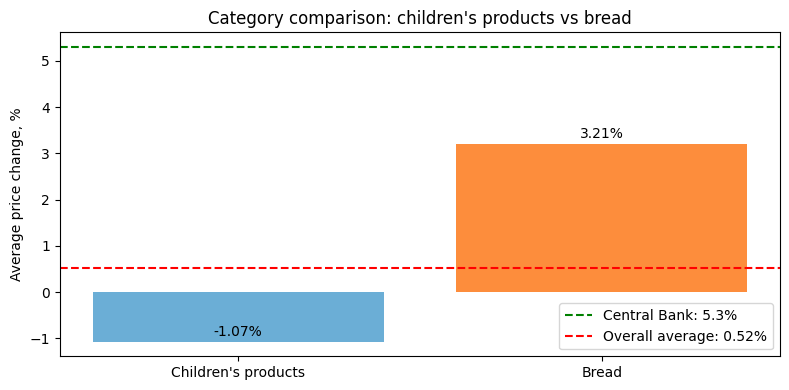

Children's category (Товары для детей): -1.07% — close to zero, prices barely moved.
Bread category (Хлеб): 3.21% — a more noticeable change than in children's products.


In [15]:
if len(compare_df) >= 2:
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(compare_df['Group'], compare_df['Avg delta, %'], color=['#6baed6', '#fd8d3c'])
    ax.axhline(CB_INFLATION_PCT, color='green', linestyle='--', label=f'Central Bank: {CB_INFLATION_PCT}%')
    ax.axhline(avg_delta_pct, color='red', linestyle='--', label=f'Overall average: {avg_delta_pct:.2f}%')
    ax.set_ylabel('Average price change, %')
    ax.set_title("Category comparison: children's products vs bread")
    for bar, val in zip(bars, compare_df['Avg delta, %']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f'{val:.2f}%', ha='center', va='bottom')
    ax.legend()
    plt.tight_layout()
    plt.show()

    children_row = compare_df.loc[compare_df['Group'] == "Children's products"].iloc[0]
    bread_row = compare_df.loc[compare_df['Group'] == 'Bread'].iloc[0]

    print(
        f"Children's category ({children_row['Category']}): "
        f"{children_row['Avg delta, %']:.2f}% — close to zero, prices barely moved."
    )
    print(
        f"Bread category ({bread_row['Category']}): "
        f"{bread_row['Avg delta, %']:.2f}% — a more noticeable change than in children's products."
    )

## 8. Conclusions

We compare the **average percentage delta** across the VkusVill basket with the Central Bank's official estimate (5.3%).

| Situation | Interpretation |
|-----------|----------------|
| Average delta **rose significantly** (close to 5.3%) | The Central Bank estimate looks plausible for our basket |
| Average delta **is near zero** | Prices barely moved in the sample — the Central Bank is not "lying", but the annual 5.3% did not show up over this short period |
| Average delta is **negative** or well below 5.3% | The official estimate looks too high relative to observed VkusVill prices — worth discussing methodology and limitations |

**Consumer basket insight:** picking one staple per CPI group gives a transparent mini-basket; its average change can differ from the all-products average.

**Category-level insight:** the overall average can hide opposite trends — some categories (e.g. children's products) stay flat, while others (e.g. bread) move more.

**Model limitations:**
- one retail chain (VkusVill), not the whole economy;
- observation period is shorter than a year, while 5.3% is an annual figure;
- the product basket changes (new/removed items);
- simplified comparison, suitable for a student project.

In [16]:
diff_pp = avg_delta_pct - CB_INFLATION_PCT

if avg_delta_pct >= CB_INFLATION_PCT * 0.7:
    verdict = (
        f'Average delta {avg_delta_pct:.2f}% is close to the Central Bank estimate ({CB_INFLATION_PCT}%). '
        'For our basket, the official figure looks plausible.'
    )
elif abs(avg_delta_pct) < 1.0:
    verdict = (
        f'Average delta {avg_delta_pct:.2f}% is near zero (deviation from CB: {diff_pp:+.2f} pp). '
        'Prices in the sample barely moved — the annual Central Bank estimate is not directly confirmed over this short period.'
    )
else:
    verdict = (
        f'Average delta {avg_delta_pct:.2f}% is noticeably below the Central Bank estimate '
        f'({CB_INFLATION_PCT}%, difference {diff_pp:+.2f} pp). '
        'Based on VkusVill data, the official estimate looks too high — a good topic for methodology discussion.'
    )

print(verdict)
print(f'\nPrice increased: {increased} ({increased / len(pairs_df) * 100:.1f}%)')
print(f'Unchanged: {unchanged} ({unchanged / len(pairs_df) * 100:.1f}%)')
print(f'Price decreased: {decreased} ({decreased / len(pairs_df) * 100:.1f}%)')

Average delta 0.52% is near zero (deviation from CB: -4.78 pp). Prices in the sample barely moved — the annual Central Bank estimate is not directly confirmed over this short period.

Price increased: 2580 (8.8%)
Unchanged: 25171 (86.1%)
Price decreased: 1493 (5.1%)


## 9. Word Cloud — Product Compositions

Word cloud from product **compositions** (ingredient lists). One record per product (`url`).

**Phrase length:** WordCloud's built-in `collocations=True` only supports **2-word** phrases (bigrams). For **3- or 4-word** phrases we build n-grams manually and use `generate_from_frequencies()` — set `NGRAM_LENGTH` below.

Requires: `pip install wordcloud`

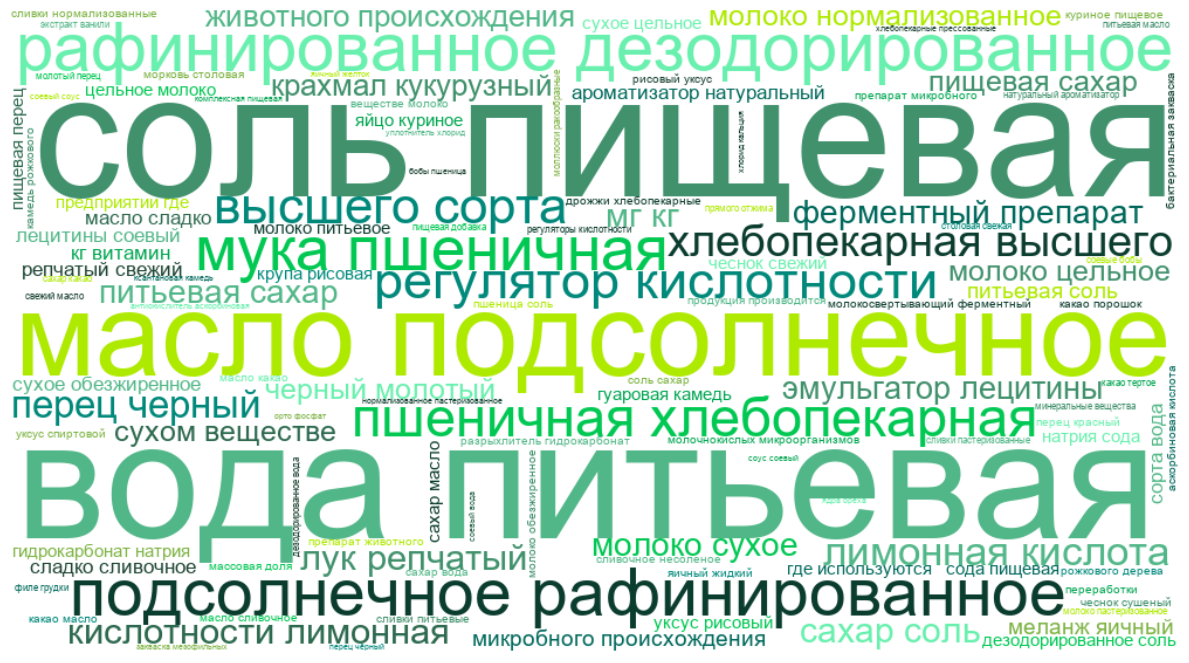

In [ ]:
import re
from pathlib import Path
from wordcloud import WordCloud

text_df = client.query_df(f"""
    SELECT any(composition) AS composition
    FROM {DB}.{TABLE}
    WHERE url IS NOT NULL
    GROUP BY url
""")
text_df = text_df[text_df['composition'].notna() & (text_df['composition'].str.strip() != '')]

RU_STOPWORDS = {
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты',
    'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из',
    'ему', 'для', 'мы', 'их', 'чем', 'была', 'при', 'это', 'эта', 'этот', 'эти', 'этом', 'или', 'также', 'может',
    'состав', 'состав:', 'описание', 'продукт', 'продукты', 'содержать', 'следы', 'возможно', 'наличие',
    'the', 'and', 'or', 'of', 'in', 'to', 'a', 'is', 'for', 'on', 'with', 'doo', 'ooo', 'ооо', 'зао', 'пао',
}

CONTRAST_GREENS = [
    '#0B3D2E', '#1B4332', '#2D6A4F', '#40916C', '#00A651', '#52B788',
    '#00695C', '#00897B', '#00C853', '#69F0AE', '#AEEA00', '#7CB342',
]


def prepare_text(series):
    parts = series.dropna().astype(str)
    parts = parts[parts.str.strip() != '']
    text = ' '.join(parts.tolist()).lower()
    text = re.sub(r'[^а-яёa-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def green_color_func(word, font_size, position, orientation, font_path, random_state, **kwargs):
    return CONTRAST_GREENS[hash(word) % len(CONTRAST_GREENS)]


def clean_composition_text(text):
    """Remove energy-unit fragments (кДж, МДж) and isolated letters м/д/ж."""
    text = re.sub(
        r'\b(?:мд|дж|кдж|мдж)\b|\bм\s+д\b|\bд\s+ж\b|\bк\s+д\s+ж\b',
        ' ',
        text,
        flags=re.I,
    )
    # single letters left after splitting кДж / МДж in nutritional lines
    text = re.sub(r'\b[мдж]\b', ' ', text, flags=re.I)
    return re.sub(r'\s+', ' ', text).strip()


from collections import Counter

NGRAM_LENGTH = 3  # change to 3 or 4 for phrase length in the cloud


def tokenize_composition(text, stopwords):
    return [w for w in text.split() if len(w) >= 2 and w not in stopwords]


def ngram_frequencies(tokens, n):
    if len(tokens) < n:
        return {}
    phrases = (' '.join(tokens[i : i + n]) for i in range(len(tokens) - n + 1))
    return Counter(phrases)


font_path = Path('C:/Windows/Fonts/arial.ttf')
font_path = str(font_path) if font_path.exists() else None

comp_stopwords = RU_STOPWORDS | {'мд', 'дж', 'кдж', 'мдж', 'м', 'д', 'ж', 'ккал'}

composition_text = clean_composition_text(prepare_text(text_df['composition']))
tokens = tokenize_composition(composition_text, comp_stopwords)
phrase_freq = ngram_frequencies(tokens, NGRAM_LENGTH)

wc_comp = WordCloud(
    width=1000,
    height=550,
    background_color='white',
    font_path=font_path,
    collocations=False,
    color_func=green_color_func,
    max_words=120,
    random_state=42,
).generate_from_frequencies(phrase_freq)

plt.figure(figsize=(12, 7))
plt.imshow(wc_comp, interpolation='bilinear')
plt.axis('off')
plt.title(f'Product compositions — top {NGRAM_LENGTH}-word phrases')
plt.tight_layout()
plt.show()